In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
 )

In [130]:
df=pd.read_csv('data/transactions_expanded.csv')


In [131]:
pd.set_option('display.max_columns', None)

print(df.head())
print(df.info())
print(df.shape)
print(df.describe())


  transaction_id customer_id       card_number  \
0    TX_a0ad2a2a  CUST_72886  6646734767813109   
1    TX_3599c101  CUST_70474   376800864692727   
2    TX_a9461c6d  CUST_10715  5251909460951913   
3    TX_7be21fc4  CUST_16193   376079286931183   
4    TX_150f490b  CUST_87572  6172948052178810   

                          timestamp merchant_category merchant_type  \
0  2024-09-30 00:00:01.034820+00:00        Restaurant     fast_food   
1  2024-09-30 00:00:01.764464+00:00     Entertainment        gaming   
2  2024-09-30 00:00:02.273762+00:00           Grocery      physical   
3  2024-09-30 00:00:02.297466+00:00               Gas         major   
4  2024-09-30 00:00:02.544063+00:00        Healthcare       medical   

         merchant     amount currency    country          city city_size  \
0       Taco Bell     294.87      GBP         UK  Unknown City    medium   
1           Steam    3368.97      BRL     Brazil  Unknown City    medium   
2     Whole Foods  102582.38      JPY      J

In [132]:
print(df.isna().sum())


transaction_id         0
customer_id            0
card_number            0
timestamp              0
merchant_category      0
merchant_type          0
merchant               0
amount                 0
currency               0
country                0
city                   0
city_size              0
card_type              0
card_present           0
device                 0
channel                0
device_fingerprint     0
ip_address             0
distance_from_home     0
high_risk_merchant     0
transaction_hour       0
weekend_transaction    0
is_fraud               0
num_transactions       0
total_amount           0
unique_merchants       0
unique_countries       0
max_single_amount      0
dtype: int64


In [133]:
df['card_number'] = df['card_number'].astype(str)


In [134]:
# Select categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Loop through each categorical column
for col in categorical_cols:
    print(f"\nColumn: {col}")
    # Count unique values
    print("Number of unique values:", df[col].nunique())
    
    # Show top 10 most frequent categories
    print(df[col].value_counts().head(10))
    
    # Optional: check for unusual/rare categories
    rare_count = (df[col].value_counts() < 10).sum()
    if rare_count > 0:
        print(f"Number of rare categories (less than 10 occurrences): {rare_count}")

/tmp/ipykernel_214606/1241759941.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns



Column: transaction_id
Number of unique values: 7477306
transaction_id
TX_eef2ac1b    3
TX_891636c5    3
TX_f4ea6740    3
TX_9c2d174f    3
TX_4e6f041a    3
TX_18d56778    3
TX_706baadf    3
TX_87660936    2
TX_fb4eb4bb    2
TX_3ce26d57    2
Name: count, dtype: int64
Number of rare categories (less than 10 occurrences): 7477306

Column: customer_id
Number of unique values: 4869
customer_id
CUST_91730    4015
CUST_24836    3767
CUST_87928    3756
CUST_81009    3744
CUST_77434    3728
CUST_12255    3699
CUST_49715    3667
CUST_88176    3664
CUST_79625    3655
CUST_41245    3623
Name: count, dtype: int64

Column: card_number
Number of unique values: 5000
card_number
5477547023755807    2000
5852026285191329    2000
4407089701966503    2000
374433185517167     2000
5897641518982067    1999
4847658373558802    1999
4560981641873273    1999
379813826706409     1999
4736602940696202    1999
4199431871226379    1999
Name: count, dtype: int64

Column: timestamp
Number of unique values: 7483754


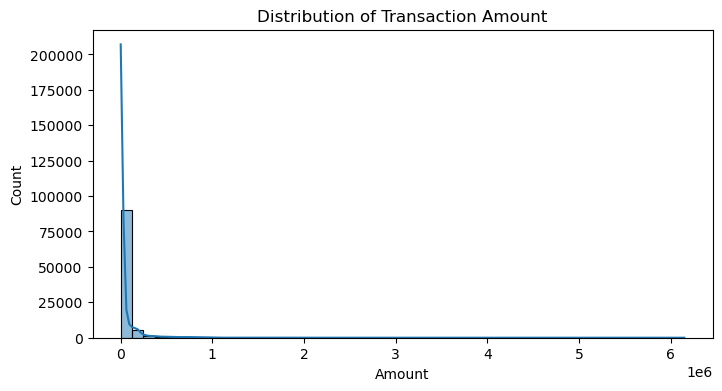

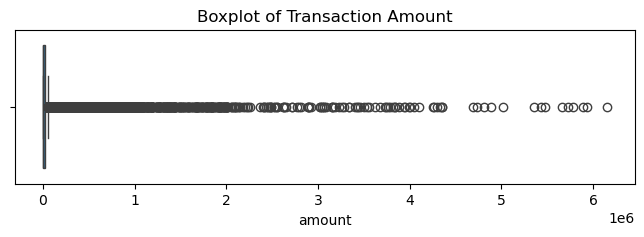

In [135]:

# Sample 100k rows for plotting
df_sample = df.sample(100000, random_state=42)

plt.figure(figsize=(8,4))
sns.histplot(df_sample['amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df_sample['amount'])
plt.title("Boxplot of Transaction Amount")
plt.show()

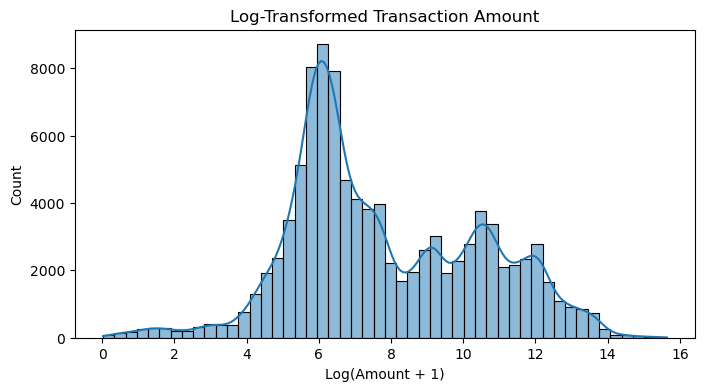

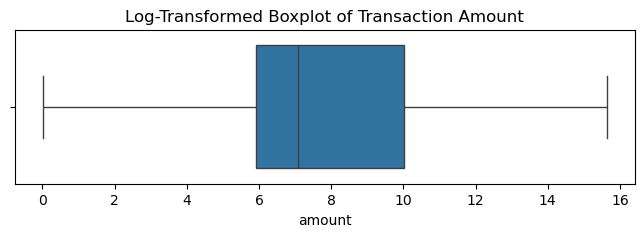

In [136]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df_sample['amount']), bins=50, kde=True)
plt.title("Log-Transformed Transaction Amount")
plt.xlabel("Log(Amount + 1)")
plt.show()
plt.figure(figsize=(8,2))
sns.boxplot(x=np.log1p(df_sample['amount']))
plt.title("Log-Transformed Boxplot of Transaction Amount")
plt.show()

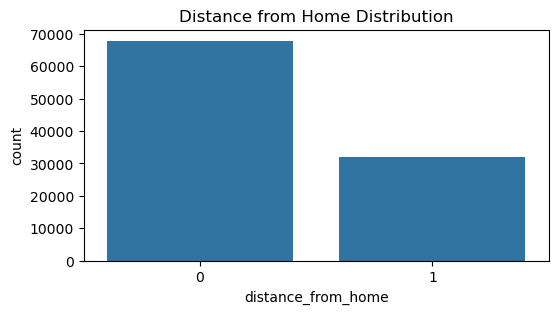

In [137]:
plt.figure(figsize=(6,3))
sns.countplot(x='distance_from_home', data=df_sample)
plt.title("Distance from Home Distribution")
plt.show()

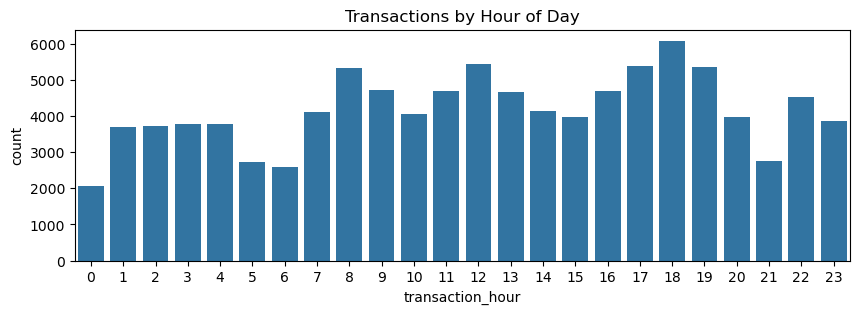

In [138]:
plt.figure(figsize=(10,3))
sns.countplot(x='transaction_hour', data=df_sample)
plt.title("Transactions by Hour of Day")
plt.show()

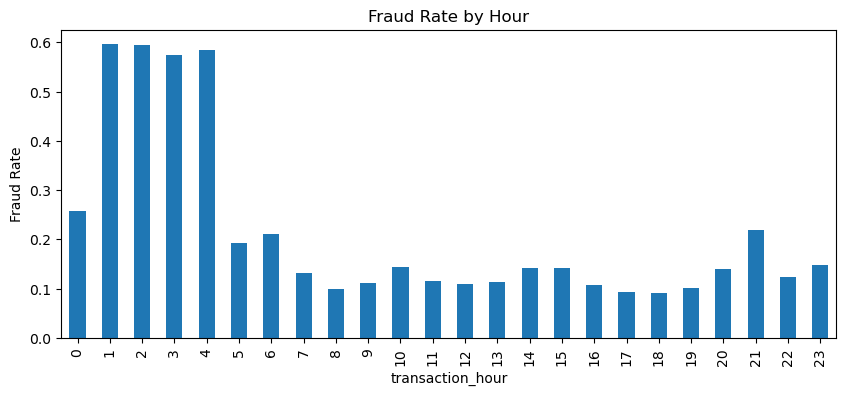

In [139]:
fraud_by_hour = df_sample.groupby('transaction_hour')['is_fraud'].mean()

plt.figure(figsize=(10,4))
fraud_by_hour.plot(kind='bar')
plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Rate")
plt.show()

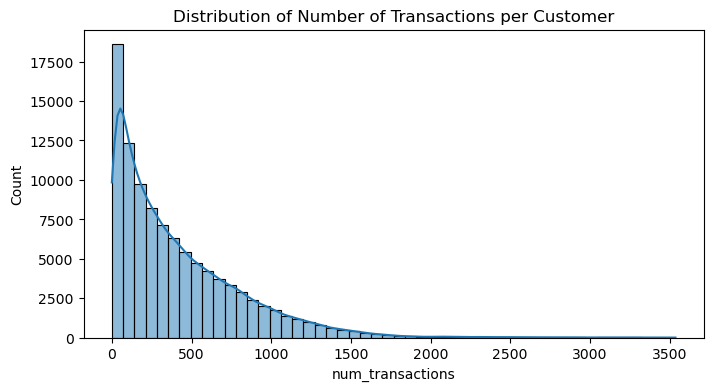

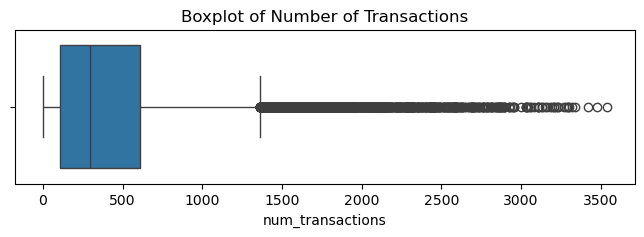

In [140]:
plt.figure(figsize=(8,4))
sns.histplot(df_sample['num_transactions'], bins=50, kde=True)
plt.title("Distribution of Number of Transactions per Customer")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df_sample['num_transactions'])
plt.title("Boxplot of Number of Transactions")
plt.show()

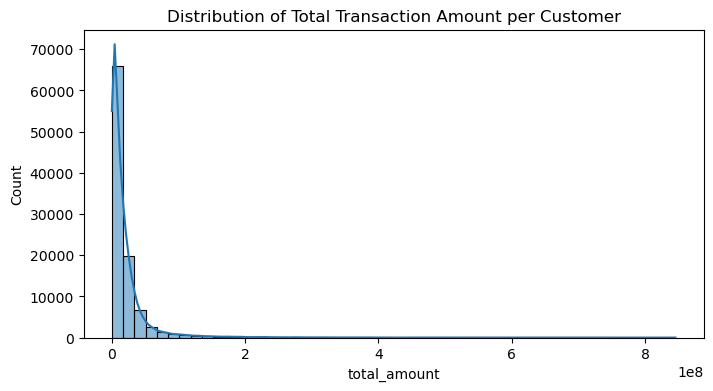

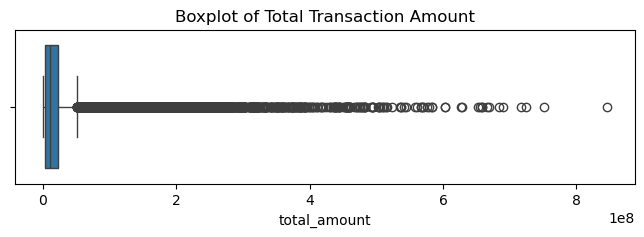

In [141]:
plt.figure(figsize=(8,4))
sns.histplot(df_sample['total_amount'], bins=50, kde=True)
plt.title("Distribution of Total Transaction Amount per Customer")
plt.show()

plt.figure(figsize=(8,2))
sns.boxplot(x=df_sample['total_amount'])
plt.title("Boxplot of Total Transaction Amount")
plt.show()

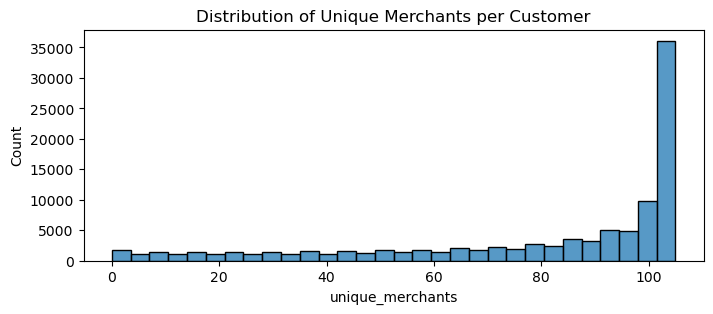

In [142]:
plt.figure(figsize=(8,3))
sns.histplot(df_sample['unique_merchants'], bins=30, kde=False)
plt.title("Distribution of Unique Merchants per Customer")
plt.show()

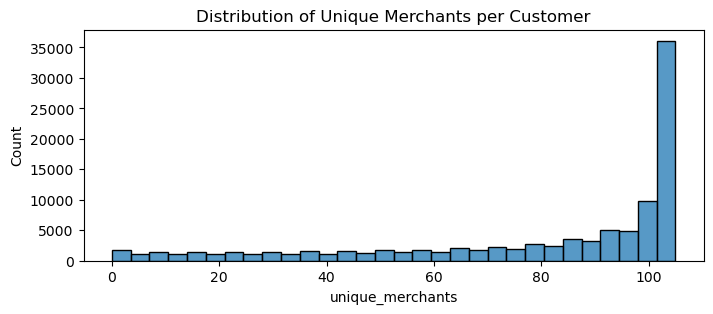

In [143]:
plt.figure(figsize=(8,3))
sns.histplot(df_sample['unique_merchants'], bins=30, kde=False)
plt.title("Distribution of Unique Merchants per Customer")
plt.show()

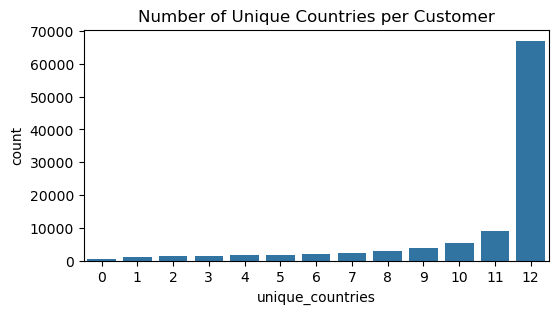

In [144]:
plt.figure(figsize=(6,3))
sns.countplot(x='unique_countries', data=df_sample)
plt.title("Number of Unique Countries per Customer")
plt.show()

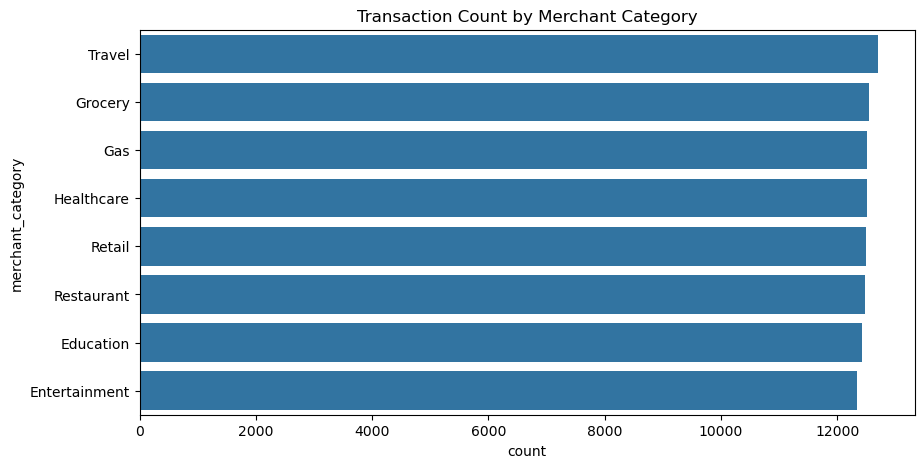

In [145]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='merchant_category',
    data=df_sample,
    order=df_sample['merchant_category'].value_counts().index
)
plt.title("Transaction Count by Merchant Category")
plt.show()

In [146]:
print(pd.crosstab(df_sample['merchant_category'], df_sample['is_fraud'])   )
fraud_rate = df_sample.groupby('merchant_category')['is_fraud'].mean()
print(fraud_rate)

is_fraud           False  True 
merchant_category              
Education           9924   2499
Entertainment      10024   2317
Gas                10003   2511
Grocery            10005   2536
Healthcare         10005   2506
Restaurant         10014   2459
Retail             10073   2427
Travel             10178   2519
merchant_category
Education        0.201159
Entertainment    0.187748
Gas              0.200655
Grocery          0.202217
Healthcare       0.200304
Restaurant       0.197146
Retail           0.194160
Travel           0.198393
Name: is_fraud, dtype: float64


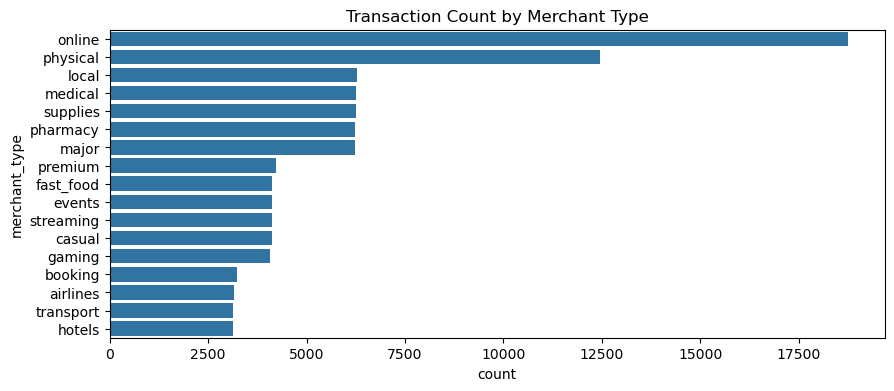

In [147]:
plt.figure(figsize=(10,4))
sns.countplot(
    y='merchant_type',
    data=df_sample,
    order=df_sample['merchant_type'].value_counts().index
)
plt.title("Transaction Count by Merchant Type")
plt.show()

In [148]:
df_sample.groupby('merchant_type')['is_fraud'].mean()

merchant_type
airlines     0.185489
booking      0.208385
casual       0.197187
events       0.191041
fast_food    0.202130
gaming       0.186582
hotels       0.200891
local        0.197107
major        0.204242
medical      0.201181
online       0.195455
pharmacy     0.199423
physical     0.202857
premium      0.192226
streaming    0.185607
supplies     0.203005
transport    0.198600
Name: is_fraud, dtype: float64

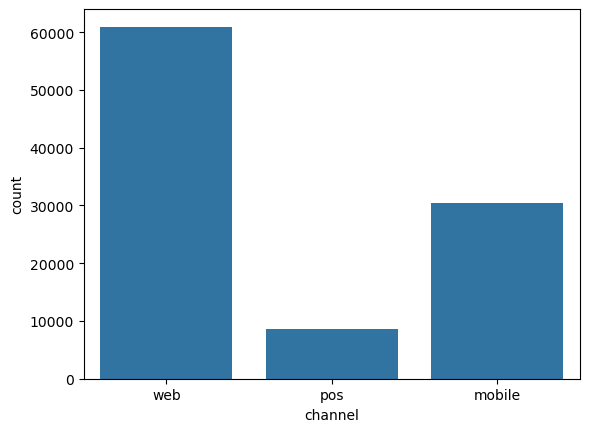

channel
mobile    0.121515
pos       1.000000
web       0.121700
Name: is_fraud, dtype: float64

In [149]:
sns.countplot(x='channel', data=df_sample)
plt.show()

pd.crosstab(df_sample['channel'], df_sample['is_fraud'])

df_sample.groupby('channel')['is_fraud'].mean()

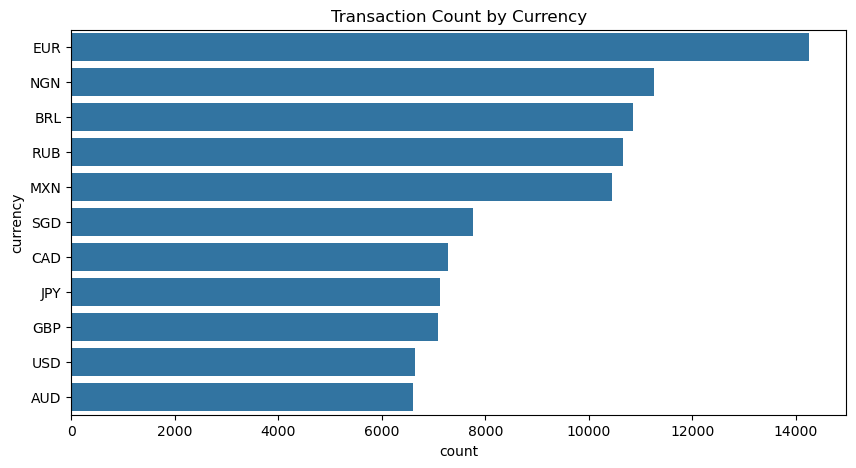

currency
AUD    0.070369
BRL    0.373331
CAD    0.065495
EUR    0.069645
GBP    0.070148
JPY    0.070055
MXN    0.379215
NGN    0.344870
RUB    0.374906
SGD    0.062597
USD    0.069194
Name: is_fraud, dtype: float64

In [150]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='currency',
    data=df_sample,
    order=df_sample['currency'].value_counts().index
)
plt.title("Transaction Count by Currency")
plt.show()
df_sample.groupby('currency')['is_fraud'].mean()

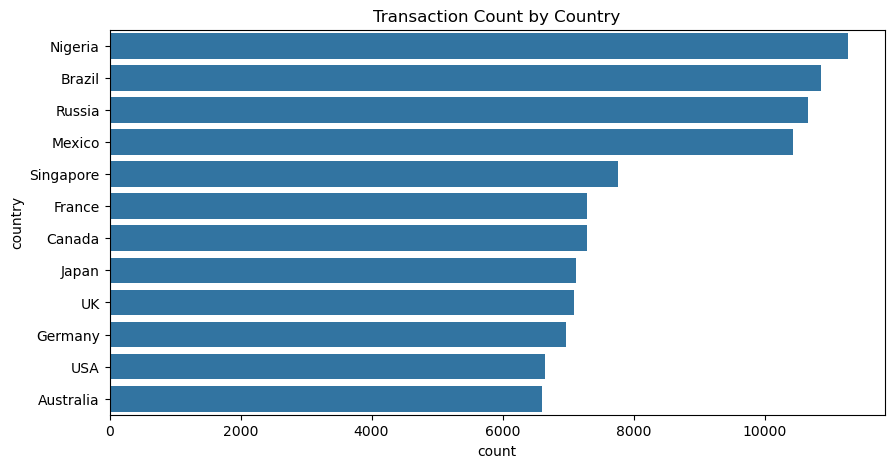

country
Australia    0.070369
Brazil       0.373331
Canada       0.065495
France       0.070380
Germany      0.068876
Japan        0.070055
Mexico       0.379215
Nigeria      0.344870
Russia       0.374906
Singapore    0.062597
UK           0.070148
USA          0.069194
Name: is_fraud, dtype: float64

In [151]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='country',
    data=df_sample,
    order=df_sample['country'].value_counts().index
)
plt.title("Transaction Count by Country")
plt.show()
df_sample.groupby('country')['is_fraud'].mean()

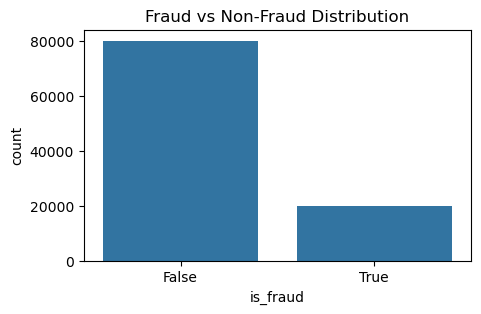

is_fraud
False    0.80226
True     0.19774
Name: proportion, dtype: float64

In [152]:
plt.figure(figsize=(5,3))
sns.countplot(x='is_fraud', data=df_sample)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()
df_sample['is_fraud'].value_counts(normalize=True)

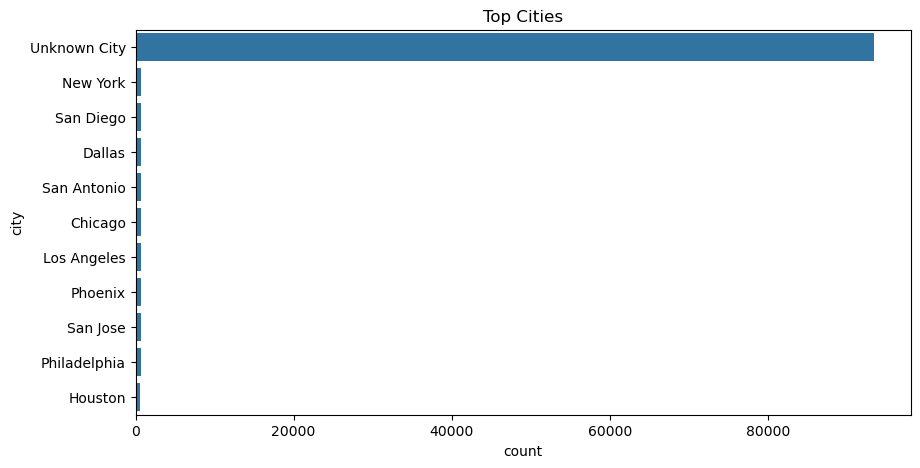

city
Chicago         0.041543
Dallas          0.083578
Houston         0.065495
Los Angeles     0.094880
New York        0.063830
Philadelphia    0.074250
Phoenix         0.071429
San Antonio     0.048889
San Diego       0.071839
San Jose        0.077165
Unknown City    0.206894
Name: is_fraud, dtype: float64

In [153]:
top_cities = df_sample['city'].value_counts().head(15).index

plt.figure(figsize=(10,5))
sns.countplot(
    y='city',
    data=df_sample[df_sample['city'].isin(top_cities)],
    order=top_cities
)
plt.title("Top Cities")
plt.show()
df_sample.groupby('city')['is_fraud'].mean()

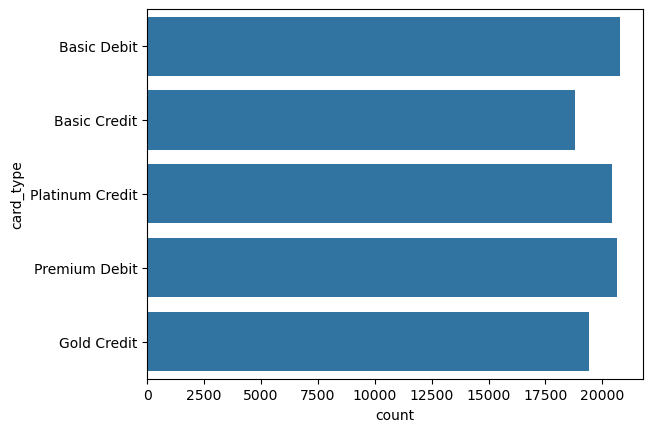

card_type
Basic Credit       0.198434
Basic Debit        0.196059
Gold Credit        0.196720
Platinum Credit    0.196146
Premium Debit      0.201338
Name: is_fraud, dtype: float64

In [154]:
sns.countplot(y='card_type', data=df_sample)
plt.show()

df_sample.groupby('card_type')['is_fraud'].mean()

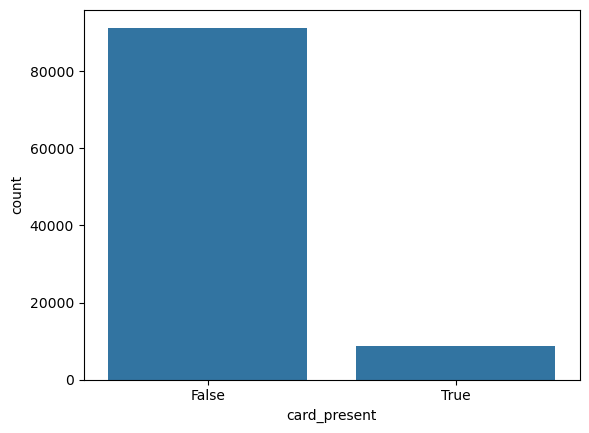

card_present
False    0.121639
True     1.000000
Name: is_fraud, dtype: float64

In [155]:
sns.countplot(x='card_present', data=df_sample)
plt.show()

df_sample.groupby('card_present')['is_fraud'].mean()

In [159]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")
df = df.sort_values(["customer_id", "timestamp"])

df["time_diff"] = df.groupby("customer_id")["timestamp"].diff().dt.total_seconds()
df["time_diff"] = df["time_diff"].fillna(0)

user_avg = df.groupby("customer_id")["amount_log"].transform("mean")

df["amount_vs_avg"] = df["amount_log"] - user_avg
df = df.sort_values(["customer_id", "timestamp"])
df.set_index("timestamp", inplace=True)

df["tx_last_30min"] = df.groupby("customer_id")["amount_log"].transform(
    lambda x: x.rolling("30min").count()
)

df.reset_index(inplace=True)
df["tx_last_30min"] = df["tx_last_30min"].fillna(0)

KeyError: 'Column not found: amount_log'

In [64]:

df['amount_log'] = np.log1p(df['amount'])
df['total_amount_log'] = np.log1p(df['total_amount'])
df['max_single_amount_log'] = np.log1p(df['max_single_amount'])
df['num_transactions_log'] = np.log1p(df['num_transactions'])
df = df.drop(columns=[
    'amount',
    'total_amount',
    'max_single_amount',
    'num_transactions'
])

In [ ]:
drop_cols = [
    'transaction_id',
    'customer_id',
    'card_number',
    'device_fingerprint',
    'ip_address',
    'timestamp',
    'merchant',
    'city'
 ]

df = df.drop(columns=drop_cols, errors='ignore')

In [66]:
df = df.drop(columns=['channel', 'card_present'])

In [ ]:
df = pd.get_dummies(df, drop_first=True)

is_fraud                 1.000000
distance_from_home       0.634459
amount_log               0.079369
max_single_amount_log    0.026131
total_amount_log         0.019787
unique_countries         0.009046
num_transactions_log     0.007989
unique_merchants         0.006932
high_risk_merchant       0.000373
weekend_transaction      0.000026
transaction_hour        -0.279624
Name: is_fraud, dtype: float64


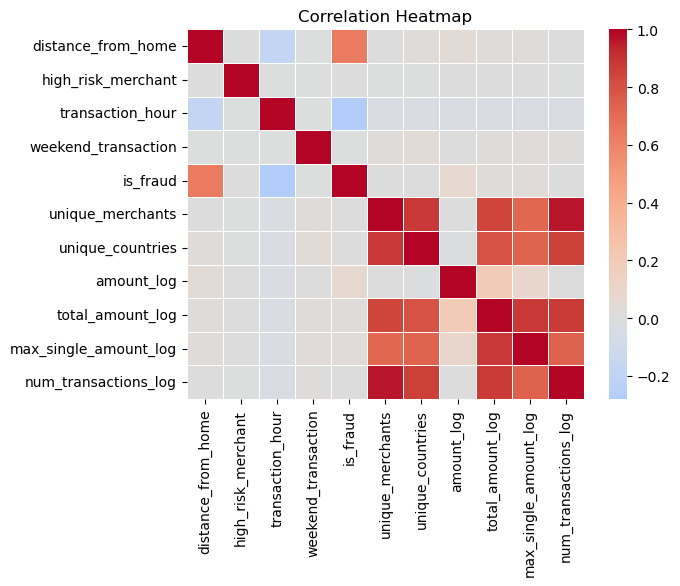

In [69]:
print(df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


In [70]:
sample_df = df.sample(n=100000, random_state=42).copy()
sample_df["is_fraud"] = sample_df["is_fraud"].astype(int)

X_sample = sample_df.drop(columns=["is_fraud"])
y_sample = sample_df["is_fraud"]

discrete_mask = [
    X_sample[col].dtype == bool or X_sample[col].nunique() <= 10
    for col in X_sample.columns
]


In [74]:
X_sample = X_sample.drop(columns=X_sample.select_dtypes(include=["object"]).columns)
mi_scores = mutual_info_classif(
    X_sample,
    y_sample,
    discrete_features=[
        X_sample[col].dtype == bool or X_sample[col].nunique() <= 10
        for col in X_sample.columns
    ],
    random_state=42
)

mi_series = pd.Series(mi_scores, index=X_sample.columns).sort_values(ascending=False)
print(mi_series.head(20))

distance_from_home       0.197320
amount_log               0.095615
transaction_hour         0.072349
unique_countries         0.009361
total_amount_log         0.001936
num_transactions_log     0.000851
high_risk_merchant       0.000022
weekend_transaction      0.000013
unique_merchants         0.000000
max_single_amount_log    0.000000
dtype: float64


In [75]:
print(df.columns)

Index(['merchant_category', 'merchant_type', 'currency', 'country',
       'city_size', 'card_type', 'device', 'distance_from_home',
       'high_risk_merchant', 'transaction_hour', 'weekend_transaction',
       'is_fraud', 'unique_merchants', 'unique_countries', 'amount_log',
       'total_amount_log', 'max_single_amount_log', 'num_transactions_log'],
      dtype='str')


In [77]:
df["is_night"] = (df["transaction_hour"] <= 4).astype(int)


In [81]:
cat_cols = [
    "currency",
    "country",
    "device",
    "card_type",
    "city_size"
]
drop_cols = [
    "merchant_category",
    "merchant_type"
]

In [82]:
df = df.drop(columns=drop_cols)

df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [84]:
df = df.drop(columns=[
    "high_risk_merchant",
    "weekend_transaction",
    "unique_merchants",
    "max_single_amount_log",
    "num_transactions_log"
])


KeyError: "['high_risk_merchant', 'weekend_transaction', 'unique_merchants', 'max_single_amount_log', 'num_transactions_log'] not found in axis"

In [85]:
df = df.drop(columns=["total_amount_log"])  # if you want simpler model

In [88]:
num_cols = [
    "distance_from_home",
    "transaction_hour",
    "unique_countries",
    "amount_log",
    "is_night",
]
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [90]:
df["night_far"] = df["is_night"] * df["distance_from_home"]
df["night_high_amount"] = df["is_night"] * df["amount_log"]

In [126]:
df.columns

Index(['distance_from_home', 'transaction_hour', 'is_fraud',
       'unique_countries', 'amount_log', 'is_night', 'currency_BRL',
       'currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_JPY',
       'currency_MXN', 'currency_NGN', 'currency_RUB', 'currency_SGD',
       'currency_USD', 'country_Brazil', 'country_Canada', 'country_France',
       'country_Germany', 'country_Japan', 'country_Mexico', 'country_Nigeria',
       'country_Russia', 'country_Singapore', 'country_UK', 'country_USA',
       'device_Chip Reader', 'device_Chrome', 'device_Edge', 'device_Firefox',
       'device_Magnetic Stripe', 'device_NFC Payment', 'device_Safari',
       'device_iOS App', 'card_type_Basic Debit', 'card_type_Gold Credit',
       'card_type_Platinum Credit', 'card_type_Premium Debit',
       'city_size_medium', 'night_far', 'night_high_amount'],
      dtype='str')

## BEFORE ADDING VELOCITY FEATURES

In [127]:

# Features and labels
columns_staying=['distance_from_home', 'transaction_hour', 'is_fraud',
       'unique_countries', 'amount_log', 'is_night', 'currency_BRL',
       'currency_CAD', 'currency_EUR', 'currency_GBP', 'currency_JPY',
       'currency_MXN', 'currency_NGN', 'currency_RUB', 'currency_SGD',
       'currency_USD', 'country_Brazil', 'country_Canada', 'country_France',
       'country_Germany', 'country_Japan', 'country_Mexico', 'country_Nigeria',
       'country_Russia', 'country_Singapore', 'country_UK', 'country_USA',
       'device_Chip Reader', 'device_Chrome', 'device_Edge', 'device_Firefox',
       'device_Magnetic Stripe', 'device_NFC Payment', 'device_Safari',
       'device_iOS App', 'card_type_Basic Debit', 'card_type_Gold Credit',
       'card_type_Platinum Credit', 'card_type_Premium Debit',
       'city_size_medium', 'night_far', 'night_high_amount'],

X = df[columns_staying]
y = df["is_fraud"].astype(int)

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

KeyboardInterrupt: 

In [108]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.15
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [109]:
test_scores = -model.decision_function(X_test)

# predictions (-1 → anomaly → 1)
y_pred = (model.predict(X_test) == -1).astype(int)

y_true = y_test

print(classification_report(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, test_scores))
print("PR-AUC:", average_precision_score(y_true, test_scores))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90   1197810
           1       0.60      0.45      0.52    298944

    accuracy                           0.83   1496754
   macro avg       0.74      0.69      0.71   1496754
weighted avg       0.82      0.83      0.82   1496754

ROC-AUC: 0.8074245449181443
PR-AUC: 0.5806419603245525


In [110]:
for p in [80, 85, 90, 95]:
    threshold = np.percentile(test_scores, p)
    y_pred = (test_scores >= threshold).astype(int)

    print(f"Percentile: {p}")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print()

Percentile: 80
Precision: 0.546148167201713
Recall: 0.5468917255405694
F1: 0.5465196934622553

Percentile: 85
Precision: 0.6046954964745916
Recall: 0.45413856775850997
F1: 0.5187130939122029

Percentile: 90
Precision: 0.6899970603169513
Recall: 0.34546938557054163
F1: 0.46041638803441665

Percentile: 95
Precision: 0.7990621117182595
Recall: 0.20006757118390067
F1: 0.320011343176571



### TRAINING ON JUST NORMAL DATA

In [125]:
normal_model = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42,
    max_samples=10000,
    n_jobs=-1
)

X_train_normal = X_train[y_train == 0]
normal_model.fit(X_train_normal)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",10000
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.15
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [124]:
test_scores = -normal_model.decision_function(X_test)

# predictions (-1 → anomaly → 1)
y_pred = (normal_model.predict(X_test) == -1).astype(int)

y_true = y_test

print(classification_report(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, test_scores))
print("PR-AUC:", average_precision_score(y_true, test_scores))

              precision    recall  f1-score   support

           0       0.92      0.85      0.89   1197810
           1       0.54      0.72      0.62    298944

    accuracy                           0.82   1496754
   macro avg       0.73      0.79      0.75   1496754
weighted avg       0.85      0.82      0.83   1496754

ROC-AUC: 0.875180901405904
PR-AUC: 0.6775719032274893


### ADDING VELOCITY (dont run fix laterrrr pc crashed)

In [ ]:
# ---- CLEAN BRANCHING PIPELINE: no velocity vs with velocity ----
df_raw = pd.read_csv("data/transactions_expanded.csv")
df_raw["card_number"] = df_raw["card_number"].astype(str)

def add_log_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    if "amount" in df_out.columns and "amount_log" not in df_out.columns:
        df_out["amount_log"] = np.log1p(df_out["amount"])
    if "total_amount" in df_out.columns and "total_amount_log" not in df_out.columns:
        df_out["total_amount_log"] = np.log1p(df_out["total_amount"])
    if "max_single_amount" in df_out.columns and "max_single_amount_log" not in df_out.columns:
        df_out["max_single_amount_log"] = np.log1p(df_out["max_single_amount"])
    if "num_transactions" in df_out.columns and "num_transactions_log" not in df_out.columns:
        df_out["num_transactions_log"] = np.log1p(df_out["num_transactions"])
    
    df_out = df_out.drop(
        columns=["amount", "total_amount", "max_single_amount", "num_transactions"],
        errors="ignore",
    )
    return df_out

def add_velocity_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    df_out["timestamp"] = pd.to_datetime(df_out["timestamp"], format="ISO8601", errors="coerce")
    df_out = df_out.sort_values(["customer_id", "timestamp"])

    # Requires amount_log; create if missing
    if "amount_log" not in df_out.columns and "amount" in df_out.columns:
        df_out["amount_log"] = np.log1p(df_out["amount"])

    df_out["time_diff"] = (
        df_out.groupby("customer_id")["timestamp"].diff().dt.total_seconds().fillna(0)
    )

    user_avg = df_out.groupby("customer_id")["amount_log"].transform("mean")
    df_out["amount_vs_avg"] = df_out["amount_log"] - user_avg

    df_out = df_out.sort_values(["customer_id", "timestamp"]).set_index("timestamp")
    df_out["tx_last_30min"] = df_out.groupby("customer_id")["amount_log"].transform(
        lambda x: x.rolling("30min").count()
    )
    df_out = df_out.reset_index()
    df_out["tx_last_30min"] = df_out["tx_last_30min"].fillna(0)
    return df_out

def final_model_prep(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()

    # Derived feature
    df_out["is_night"] = (df_out["transaction_hour"] <= 4).astype(int)

    # Drop high-leakage/high-cardinality IDs and metadata
    df_out = df_out.drop(
        columns=[
            "transaction_id",
            "customer_id",
            "card_number",
            "device_fingerprint",
            "ip_address",
            "timestamp",
            "merchant",
            "city",
        ],
        errors="ignore",
    )

    # Optional feature pruning from your earlier trials
    df_out = df_out.drop(
        columns=[
            "high_risk_merchant",
            "weekend_transaction",
            "unique_merchants",
            "max_single_amount_log",
            "num_transactions_log",
            "total_amount_log",
        ],
        errors="ignore",
    )

    # Keep merchant_category / merchant_type dropped as in your previous setup
    df_out = df_out.drop(columns=["merchant_category", "merchant_type"], errors="ignore")

    cat_cols = ["currency", "country", "device", "card_type", "city_size"]
    cat_cols = [c for c in cat_cols if c in df_out.columns]
    df_out = pd.get_dummies(df_out, columns=cat_cols, drop_first=True)

    # Scale numeric columns if they exist
    num_cols = [
        "distance_from_home",
        "transaction_hour",
        "unique_countries",
        "amount_log",
        "is_night",
        "time_diff",
        "amount_vs_avg",
        "tx_last_30min",
    ]
    scale_cols = [c for c in num_cols if c in df_out.columns]
    if scale_cols:
        scaler = StandardScaler()
        df_out[scale_cols] = scaler.fit_transform(df_out[scale_cols])

    # Interaction features
    if "is_night" in df_out.columns and "distance_from_home" in df_out.columns:
        df_out["night_far"] = df_out["is_night"] * df_out["distance_from_home"]
    if "is_night" in df_out.columns and "amount_log" in df_out.columns:
        df_out["night_high_amount"] = df_out["is_night"] * df_out["amount_log"]

    return df_out

# Branch A: without velocity
df_no_velocity = final_model_prep(add_log_features(df_raw.copy()))

# Branch B: with velocity
df_with_velocity = final_model_prep(add_log_features(add_velocity_features(df_raw.copy())))

print("no_velocity shape:", df_no_velocity.shape)
print("with_velocity shape:", df_with_velocity.shape)

added_cols = sorted(set(df_with_velocity.columns) - set(df_no_velocity.columns))
print("Added columns in velocity version:", added_cols)

# Optional: persist both versions
df_no_velocity.to_parquet("data/features_no_velocity.parquet", index=False)
df_with_velocity.to_parquet("data/features_with_velocity.parquet", index=False)
print("Saved parquet files in data/")

In [ ]:
# ---- QUICK COMPARISON: same model, both versions ----
def train_eval_isoforest(df_in: pd.DataFrame, version_name: str, sample_n: int | None = 400000):
    work = df_in.copy()
    work["is_fraud"] = work["is_fraud"].astype(int)

    if sample_n is not None and len(work) > sample_n:
        # stratified-ish sample by class ratio
        fraud_part = work[work["is_fraud"] == 1]
        normal_part = work[work["is_fraud"] == 0]

        n_fraud = min(len(fraud_part), max(1, int(sample_n * fraud_part.shape[0] / work.shape[0])))
        n_normal = min(len(normal_part), sample_n - n_fraud)

        work = pd.concat(
            [
                fraud_part.sample(n=n_fraud, random_state=42),
                normal_part.sample(n=n_normal, random_state=42),
            ],
            axis=0,
        ).sample(frac=1.0, random_state=42)

    X = work.drop(columns=["is_fraud"])
    y = work["is_fraud"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = IsolationForest(
        n_estimators=100,
        contamination=0.15,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train)

    test_scores = -model.decision_function(X_test)
    y_pred = (model.predict(X_test) == -1).astype(int)

    print(f"\n=== {version_name} ===")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, test_scores))
    print("PR-AUC:", average_precision_score(y_test, test_scores))

    for p in [80, 85, 90, 95]:
        threshold = np.percentile(test_scores, p)
        y_pred_p = (test_scores >= threshold).astype(int)
        print(
            f"p={p} | Precision={precision_score(y_test, y_pred_p):.4f} "
            f"Recall={recall_score(y_test, y_pred_p):.4f} "
            f"F1={f1_score(y_test, y_pred_p):.4f}"
        )

# Run both
train_eval_isoforest(df_no_velocity, "NO VELOCITY")
train_eval_isoforest(df_with_velocity, "WITH VELOCITY")